In [2]:
import os
import torch
from PIL import Image
from tqdm import tqdm
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import f1_score,confusion_matrix
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.optim.lr_scheduler import ReduceLROnPlateau


In [3]:
torch.cuda.empty_cache()
print(f"GPU Memory Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU Memory Cached: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

GPU Memory Allocated: 0.00 GB
GPU Memory Cached: 0.00 GB


In [3]:
# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 20
NUM_CLASSES = 3
TRAIN_DIR = "../split_data/train"
TEST_DIR = "../split_data/test"
GRAD_ACCUMULATION_STEPS = 8  # Number of batches to accumulate gradients over
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * GRAD_ACCUMULATION_STEPS  # This is your effective batch size

# === Data Preparation ===
def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomRotation(20),
            transforms.RandomHorizontalFlip(),
            transforms.RandomAffine(0, shear=20, scale=(0.8, 1.2)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

class ChestXrayDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.images = self._load_images()

    def _load_images(self):
        return [
            (os.path.join(cls_dir, img), self.class_to_idx[cls])
            for cls in self.classes
            for cls_dir, _, files in os.walk(os.path.join(self.root_dir, cls))
            for img in files
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

def get_dataloaders():
    train_ds = ChestXrayDataset(TRAIN_DIR, get_transforms(train=True))
    val_ds = ChestXrayDataset(TEST_DIR, get_transforms(train=False))
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader, train_ds.classes

# === Model ===
class EfficientNetB5Model(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Load pre-trained EfficientNet B5 model
        base_model = models.efficientnet_b5(weights='IMAGENET1K_V1')
        
        # Get the feature extractor (everything except the classifier)
        self.features = nn.Sequential(*list(base_model.children())[:-1])
        
        # EfficientNet-B5 has 2048 feature dimensions
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Global average pooling
            nn.Flatten(),
            nn.Linear(2048, 512),  # EfficientNet-B5 has 2048 feature channels
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# === Training with Gradient Accumulation ===
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    # Initialize gradient accumulation step counter
    step = 0
    optimizer.zero_grad()  # Zero gradients at the beginning of the epoch
    
    for inputs, labels in tqdm(loader, desc="Training"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels) / GRAD_ACCUMULATION_STEPS  # Scale loss
        
        # Backward pass
        loss.backward()
        
        # Accumulate batch statistics
        running_loss += loss.item() * GRAD_ACCUMULATION_STEPS  # Adjust loss for reporting
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        step += 1
        
        # Update weights after accumulating gradients for specified number of steps
        if step % GRAD_ACCUMULATION_STEPS == 0:
            optimizer.step()
            optimizer.zero_grad()
    
    # Handle any remaining gradients if dataset size is not divisible by effective batch size
    if step % GRAD_ACCUMULATION_STEPS != 0:
        optimizer.step()
        optimizer.zero_grad()

    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')
    return running_loss / len(loader), acc, f1

def evaluate(model, loader, criterion, get_predictions=False):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluation"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    if get_predictions:
        return running_loss / len(loader), acc, f1, all_preds, all_labels
    return running_loss / len(loader), acc, f1

def plot_confusion_matrix(true_labels, predictions, class_names):
    """
    Plot confusion matrix using true labels and predictions
    """
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig('confusion_matrix_efficientnet_b5.png')
    plt.close()
    
    # Calculate per-class metrics
    print("\nPer-class Performance:")
    for i, class_name in enumerate(class_names):
        class_precision = cm[i, i] / cm[:, i].sum() if cm[:, i].sum() > 0 else 0
        class_recall = cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
        class_f1 = 2 * (class_precision * class_recall) / (class_precision + class_recall) if (class_precision + class_recall) > 0 else 0
        
        print(f"{class_name}:")
        print(f"  Precision: {class_precision:.4f}")
        print(f"  Recall: {class_recall:.4f}")
        print(f"  F1 Score: {class_f1:.4f}")

# === Full Training Loop ===
def train_model():
    train_loader, val_loader, class_names = get_dataloaders()
    model = EfficientNetB5Model(num_classes=NUM_CLASSES).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)  # Lower learning rate for EfficientNet
    scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=2)
    best_f1 = 0.0
    history = {'train_loss': [], 'train_acc': [], 'train_f1': [],
               'val_loss': [], 'val_acc': [], 'val_f1': []}

    print(f"Training with effective batch size: {EFFECTIVE_BATCH_SIZE} (batch_size={BATCH_SIZE}, grad_accum_steps={GRAD_ACCUMULATION_STEPS})")
    print(f"Using device: {DEVICE}")
    print(f"Model: EfficientNet-B5 with custom classifier")
    
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['train_f1'].append(tr_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        scheduler.step(val_f1)

        print(f"Train Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f} | F1: {tr_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_efficientnet_b5.pth")
            print(f"Saved best model with F1: {best_f1:.4f}")

    # Final evaluation
    print("\n=== Final Evaluation ===")
    print(f"Best Validation F1: {best_f1:.4f}")
    
    # Load best model for final evaluation and confusion matrix
    print("\n=== Generating Confusion Matrix for Best Model ===")
    model.load_state_dict(torch.load("best_model_efficientnet_b5.pth"))
    _, _, _, y_pred, y_true = evaluate(model, val_loader, criterion, get_predictions=True)
    
    # Plot and save confusion matrix
    plot_confusion_matrix(y_true, y_pred, class_names)
    print(f"Confusion matrix saved to 'confusion_matrix_efficientnet_b5.png'")
    
    # Plot training history
    plot_training_history(history)
    
    return model, history

def plot_training_history(history):
    """
    Plot training and validation metrics over epochs
    """
    plt.figure(figsize=(15, 5))
    
    # Plot loss
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot accuracy
    plt.subplot(1, 3, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot F1 score
    plt.subplot(1, 3, 3)
    plt.plot(history['train_f1'], label='Train F1')
    plt.plot(history['val_f1'], label='Val F1')
    plt.title('F1 Score over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_history_efficientnet_b5.png')
    plt.close()
    print("Training history plot saved to 'training_history_efficientnet_b5.png'")

In [4]:
if __name__ == "__main__":
    model, history = train_model()

Training with effective batch size: 64 (batch_size=8, grad_accum_steps=8)
Using device: cuda
Model: EfficientNet-B5 with custom classifier

Epoch 1/20


Evaluation: 100%|████████████████████████████████████████████████████████████████████| 172/172 [00:39<00:00,  4.34it/s]


Train Loss: 0.6810 | Acc: 0.7447 | F1: 0.7478
Val Loss: 0.3190 | Acc: 0.9135 | F1: 0.9146
Saved best model with F1: 0.9146

Epoch 2/20


Evaluation: 100%|████████████████████████████████████████████████████████████████████| 172/172 [00:38<00:00,  4.46it/s]


Train Loss: 0.3069 | Acc: 0.8976 | F1: 0.8982
Val Loss: 0.2185 | Acc: 0.9316 | F1: 0.9318
Saved best model with F1: 0.9318

Epoch 3/20


...

Train Loss: 0.1042 | Acc: 0.9636 | F1: 0.9639
Val Loss: 0.1748 | Acc: 0.9425 | F1: 0.9430

Epoch 20/20


Evaluation: 100%|████████████████████████████████████████████████████████████████████| 172/172 [00:39<00:00,  4.34it/s]


Train Loss: 0.1039 | Acc: 0.9645 | F1: 0.9648
Val Loss: 0.1791 | Acc: 0.9418 | F1: 0.9421

=== Final Evaluation ===
Best Validation F1: 0.9547

=== Generating Confusion Matrix for Best Model ===


Evaluation: 100%|████████████████████████████████████████████████████████████████████| 172/172 [00:37<00:00,  4.59it/s]


NameError: name 'confusion_matrix' is not defined

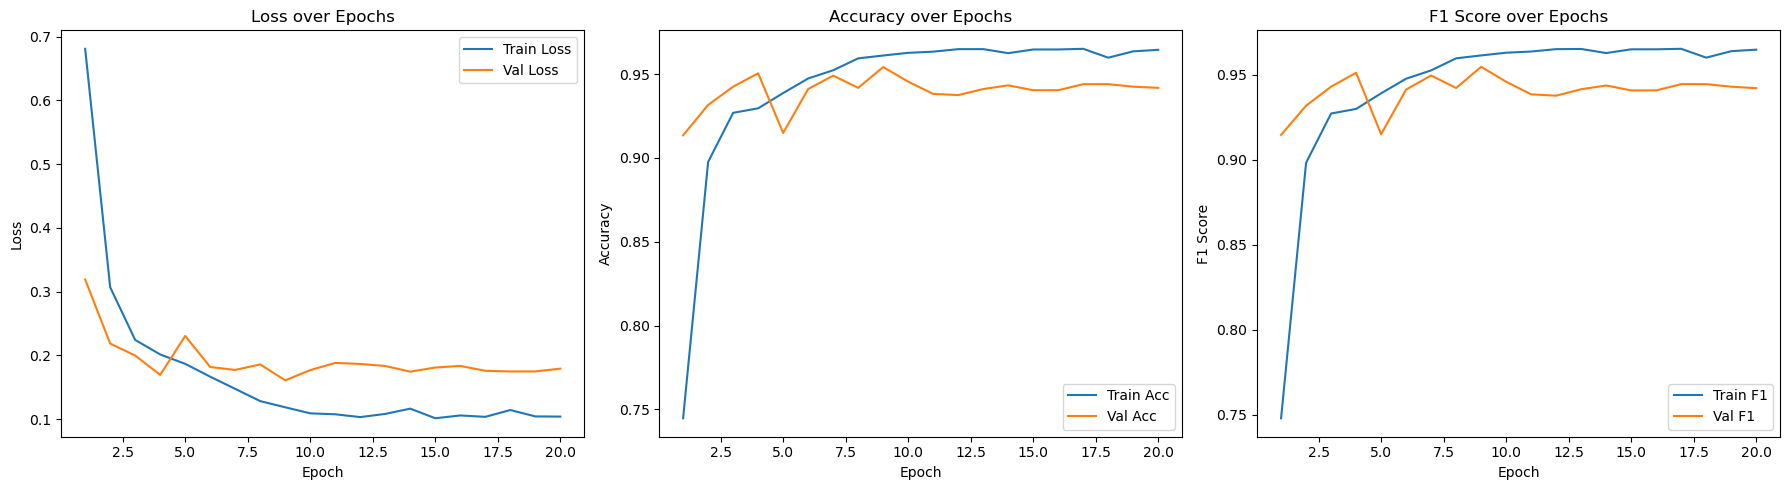

In [1]:
import matplotlib.pyplot as plt

epochs = list(range(1, 21))

train_loss = [0.6810, 0.3069, 0.2242, 0.2014, 0.1867, 0.1665, 0.1474, 0.1282, 0.1185, 0.1090,
              0.1075, 0.1031, 0.1081, 0.1164, 0.1013, 0.1057, 0.1035, 0.1142, 0.1042, 0.1039]
val_loss = [0.3190, 0.2185, 0.1997, 0.1693, 0.2304, 0.1817, 0.1771, 0.1858, 0.1608, 0.1768,
            0.1881, 0.1865, 0.1833, 0.1744, 0.1809, 0.1834, 0.1758, 0.1747, 0.1748, 0.1791]

train_acc = [0.7447, 0.8976, 0.9269, 0.9296, 0.9387, 0.9474, 0.9523, 0.9594, 0.9611, 0.9627,
             0.9634, 0.9649, 0.9649, 0.9625, 0.9647, 0.9647, 0.9651, 0.9598, 0.9636, 0.9645]
val_acc = [0.9135, 0.9316, 0.9425, 0.9505, 0.9149, 0.9411, 0.9491, 0.9418, 0.9542, 0.9455,
           0.9382, 0.9375, 0.9411, 0.9433, 0.9404, 0.9404, 0.9440, 0.9440, 0.9425, 0.9418]

train_f1 = [0.7478, 0.8982, 0.9272, 0.9299, 0.9391, 0.9477, 0.9526, 0.9597, 0.9614, 0.9630,
            0.9637, 0.9651, 0.9652, 0.9628, 0.9650, 0.9650, 0.9653, 0.9601, 0.9639, 0.9648]
val_f1 = [0.9146, 0.9318, 0.9430, 0.9512, 0.9150, 0.9413, 0.9496, 0.9422, 0.9547, 0.9459,
          0.9385, 0.9377, 0.9415, 0.9437, 0.9408, 0.9408, 0.9445, 0.9445, 0.9430, 0.9421]

plt.figure(figsize=(18, 5))

# Loss
plt.subplot(1, 3, 1)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs, train_acc, label='Train Acc' )
plt.plot(epochs, val_acc, label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


# F1 Score
plt.subplot(1, 3, 3)
plt.plot(epochs, train_f1, label='Train F1')
plt.plot(epochs, val_f1, label='Val F1')
plt.title('F1 Score over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()


plt.tight_layout()
plt.show()


In [4]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH_SIZE = 8  # Reduced for EfficientNet memory usage
EPOCHS = 20
NUM_CLASSES = 3
TRAIN_DIR = "../split_data/train"
TEST_DIR = "../split_data/test"
GRAD_ACCUMULATION_STEPS = 8
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * GRAD_ACCUMULATION_STEPS

# Data Augmentation
def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomRotation(15),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])

# Dataset
class ChestXrayDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.images = self._load_images()

    def _load_images(self):
        images = []
        for cls in self.classes:
            cls_dir = os.path.join(self.root_dir, cls)
            for img_name in os.listdir(cls_dir):
                if img_name.endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(cls_dir, img_name)
                    images.append((img_path, self.class_to_idx[cls]))
        return images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Model
class EfficientNetTransformer(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # Load pre-trained EfficientNet-B5
        base_model = models.efficientnet_b5(weights='IMAGENET1K_V1')
        
        # Extract features up to last convolutional layer
        self.cnn = nn.Sequential(*list(base_model.children())[:-2])
        
        # Transformer Head
        self.transformer_head = TransformerHead(
            input_dim=2048,  # EfficientNet-B5 feature dim
            hidden_dim=512,  # Increased for better representation
            num_classes=num_classes
        )
        
    def forward(self, x):
        # CNN Feature Extraction
        x = self.cnn(x)  # (B, 2048, 7, 7)
        
        # Flatten spatial dimensions
        x = x.mean(dim=[2, 3])  # Global Avg Pool (B, 2048)
        
        # Transformer Processing
        return self.transformer_head(x)

class TransformerHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, nhead=8, num_layers=2):
        super().__init__()
        self.projection = nn.Linear(input_dim, hidden_dim)
        
        # Transformer Encoder
        encoder_layer = TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=hidden_dim*4,
            dropout=0.2,
            activation='gelu',
            batch_first=True
        )
        self.transformer = TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, num_classes))
        
    def forward(self, x):
        x = self.projection(x).unsqueeze(1)  # (B, 1, hidden_dim)
        x = self.transformer(x)
        x = x.mean(dim=1)  # Pool sequence
        return self.classifier(x)

# Training Utilities
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    optimizer.zero_grad()
    
    for batch_idx, (inputs, labels) in enumerate(tqdm(loader, desc="Training")):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        outputs = model(inputs)
        loss = criterion(outputs, labels) / GRAD_ACCUMULATION_STEPS
        loss.backward()
        
        running_loss += loss.item() * GRAD_ACCUMULATION_STEPS
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        if (batch_idx + 1) % GRAD_ACCUMULATION_STEPS == 0:
            optimizer.step()
            optimizer.zero_grad()
    
    # Final step if remaining
    if (batch_idx + 1) % GRAD_ACCUMULATION_STEPS != 0:
        optimizer.step()
        optimizer.zero_grad()
    
    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')
    return running_loss / len(loader), acc, f1

def evaluate(model, loader, criterion, return_predictions=False):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    if return_predictions:
        return running_loss / len(loader), acc, f1, all_preds, all_labels
    return running_loss / len(loader), acc, f1

def plot_confusion_matrix(true_labels, pred_labels, class_names, filename='confusion_matrix.png'):
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(filename, bbox_inches='tight')
    plt.close()
    print(f"Confusion matrix saved to {filename}")

# Main Training Loop
def main():
    # Data Loaders
    train_dataset = ChestXrayDataset(TRAIN_DIR, get_transforms(train=True))
    val_dataset = ChestXrayDataset(TEST_DIR, get_transforms(train=False))
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Model
    model = EfficientNetTransformer(num_classes=NUM_CLASSES).to(DEVICE)
    
    # Loss and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    # Training Tracking
    best_f1 = 0.0
    history = {'train_loss': [], 'train_acc': [], 'train_f1': [],
               'val_loss': [], 'val_acc': [], 'val_f1': []}
    
    print(f"Training EfficientNet-Transformer Hybrid on {DEVICE}")
    print(f"Effective batch size: {EFFECTIVE_BATCH_SIZE}")
    
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        
        # Train
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer)
        
        # Validate
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)
        
        # Update history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        # Scheduler step
        scheduler.step(val_f1)
        
        print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        
        # Save best model
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"Saved new best model with F1: {best_f1:.4f}")
    
    # Final Evaluation with Confusion Matrix
    print("\n=== Final Evaluation ===")
    model.load_state_dict(torch.load('best_model.pth'))
    _, val_acc, val_f1, all_preds, all_labels = evaluate(
        model, val_loader, criterion, return_predictions=True
    )
    
    print(f"Best Model Metrics - Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
    
    # Confusion Matrix
    plot_confusion_matrix(
        all_labels, all_preds, 
        class_names=train_dataset.classes,
        filename='efficientnet_transformer_cm.png'
    )
    
    # Plot Training Curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.title('Loss Curve')
    plt.legend()
    
    plt.subplot(1, 3, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['val_acc'], label='Val')
    plt.title('Accuracy Curve')
    plt.legend()
    
    plt.subplot(1, 3, 3)
    plt.plot(history['train_f1'], label='Train')
    plt.plot(history['val_f1'], label='Val')
    plt.title('F1 Score Curve')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_curves.png')
    plt.close()
    print("Training curves saved to training_curves.png")



In [5]:
if __name__ == "__main__":
    main()

Training EfficientNet-Transformer Hybrid on cuda
Effective batch size: 64

Epoch 1/20


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 172/172 [00:53<00:00,  3.24it/s]


Train Loss: 0.4289 | Acc: 0.8382 | F1: 0.8386
Val Loss: 0.2205 | Acc: 0.9382 | F1: 0.9385
Saved new best model with F1: 0.9385

Epoch 2/20


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 172/172 [00:39<00:00,  4.39it/s]


Train Loss: 0.2673 | Acc: 0.9094 | F1: 0.9098
Val Loss: 0.1811 | Acc: 0.9476 | F1: 0.9480
Saved new best model with F1: 0.9480

Epoch 3/20


...

Train Loss: 0.0363 | Acc: 0.9882 | F1: 0.9882
Val Loss: 0.2091 | Acc: 0.9542 | F1: 0.9547

Epoch 20/20


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 172/172 [00:39<00:00,  4.39it/s]


Train Loss: 0.0361 | Acc: 0.9871 | F1: 0.9872
Val Loss: 0.1925 | Acc: 0.9535 | F1: 0.9540

=== Final Evaluation ===


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 172/172 [00:37<00:00,  4.55it/s]


Best Model Metrics - Acc: 0.9600, F1: 0.9605
Confusion matrix saved to efficientnet_transformer_cm.png
Training curves saved to training_curves.png
